In [1]:
# ============================================================
# SETUP: hardcoded final numbers from the completed Hindi mono run
# (no need to reload models/data/checkpoints — just building the
# summary table + charts from the recorded results)
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- try to save to Drive if this is Colab; fall back to local dir otherwise ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = '/content/drive/MyDrive/semeval_hin_mono4sep_results'
except Exception:
    OUTPUT_DIR = './semeval_hin_mono4sep_results'

final_out_dir = os.path.join(OUTPUT_DIR, 'final_results_hin')
os.makedirs(final_out_dir, exist_ok=True)

# --- best hyperparameters found during tuning ---
hin_best_alpha = 0.40   # ensemble weight (fine-tuned vs frozen), tuned on dev
FINAL_BETA_HIN = 1.00   # cross-encoder fusion weight, tuned on dev

# --- final test-set results (500 Hindi posts), Success@1/5/10 ---
hin_results_frozen     = {'success@1': 0.364, 'success@5': 0.606, 'success@10': 0.692}
hin_results_finetuned  = {'success@1': 0.366, 'success@5': 0.626, 'success@10': 0.686}
hin_results_ensemble   = {'success@1': 0.380, 'success@5': 0.664, 'success@10': 0.736}
hin_results_reranked_ft = {'success@1': 0.398, 'success@5': 0.670, 'success@10': 0.738}

print('✅ Results loaded manually. Ready to build table + charts.')

Mounted at /content/drive
✅ Results loaded manually. Ready to build table + charts.


In [2]:
# ============================================================
# FINAL CELL A: CONSOLIDATED RESULTS TABLE — all 4 stages, Hindi mono
# ============================================================
final_table = pd.DataFrame({
    'Frozen ME5-Large':                                  hin_results_frozen,
    'Fine-tuned ME5-Large (LoRA)':                        hin_results_finetuned,
    f'Ensemble (frozen+FT, α={hin_best_alpha:.2f})':      hin_results_ensemble,
    f'Ensemble + CE Rerank (β={FINAL_BETA_HIN:.2f})':     hin_results_reranked_ft,
}).T[['success@1', 'success@5', 'success@10']]

# deltas relative to the frozen baseline
deltas = final_table.subtract(final_table.loc['Frozen ME5-Large'], axis=1)
pct_deltas = (deltas / final_table.loc['Frozen ME5-Large']) * 100

print('=== Hindi Monolingual — Final Comparison ===\n')
print(final_table.round(4).to_string())
print('\n=== Δ vs Frozen baseline ===\n')
for stage in final_table.index[1:]:
    row = ', '.join(f'{m}: {deltas.loc[stage, m]:+.4f} ({pct_deltas.loc[stage, m]:+.2f}%)' for m in final_table.columns)
    print(f'{stage}: {row}')

# save
final_table.to_csv(os.path.join(final_out_dir, 'final_results_hin.csv'))
with open(os.path.join(final_out_dir, 'final_results_hin.md'), 'w') as f:
    f.write('# Hindi Monolingual Retrieval — Final Pipeline Results\n\n')
    f.write(final_table.round(4).to_markdown())
    f.write('\n\n## Δ vs Frozen Baseline\n\n')
    f.write(deltas.round(4).to_markdown())

print(f'\n💾 Saved table to: {final_out_dir}')

=== Hindi Monolingual — Final Comparison ===

                               success@1  success@5  success@10
Frozen ME5-Large                   0.364      0.606       0.692
Fine-tuned ME5-Large (LoRA)        0.366      0.626       0.686
Ensemble (frozen+FT, α=0.40)       0.380      0.664       0.736
Ensemble + CE Rerank (β=1.00)      0.398      0.670       0.738

=== Δ vs Frozen baseline ===

Fine-tuned ME5-Large (LoRA): success@1: +0.0020 (+0.55%), success@5: +0.0200 (+3.30%), success@10: -0.0060 (-0.87%)
Ensemble (frozen+FT, α=0.40): success@1: +0.0160 (+4.40%), success@5: +0.0580 (+9.57%), success@10: +0.0440 (+6.36%)
Ensemble + CE Rerank (β=1.00): success@1: +0.0340 (+9.34%), success@5: +0.0640 (+10.56%), success@10: +0.0460 (+6.65%)

💾 Saved table to: /content/drive/MyDrive/semeval_hin_mono4sep_results/final_results_hin


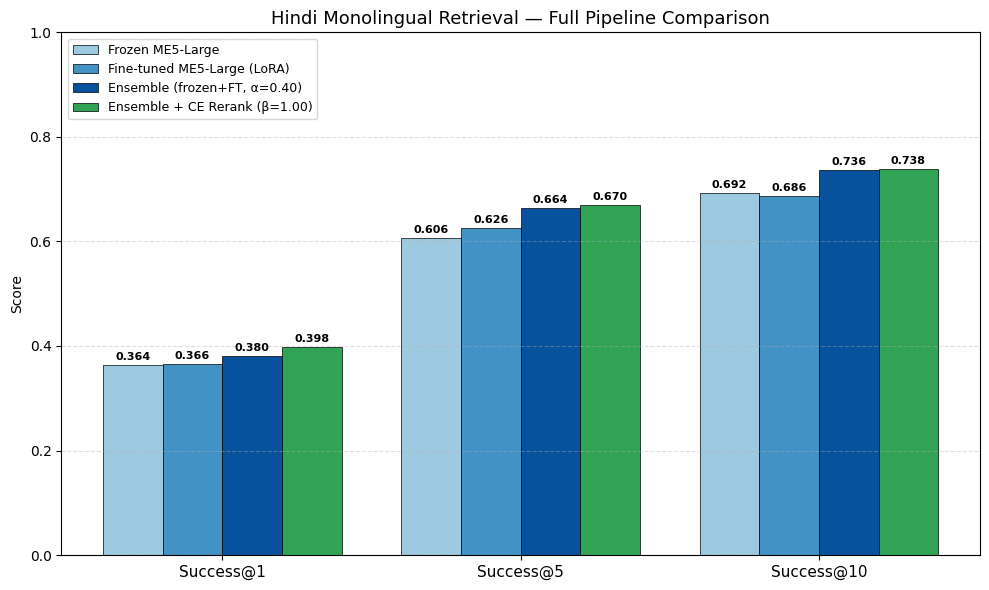

Saved chart to: /content/drive/MyDrive/semeval_hin_mono4sep_results/final_results_hin/final_comparison_bar_hin.png


In [3]:
# ============================================================
# FINAL CELL B: GROUPED BAR CHART — all 4 stages, success@1/5/10
# ============================================================
metrics = ['success@1', 'success@5', 'success@10']
stages = final_table.index.tolist()
colors = ['#9ECAE1', '#4292C6', '#08519C', '#31A354']

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics))
width = 0.8 / len(stages)

for i, stage in enumerate(stages):
    vals = final_table.loc[stage, metrics].values
    offset = (i - (len(stages) - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=stage, color=colors[i % len(colors)],
                  edgecolor='black', linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f'{h:.3f}',
                ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['Success@1', 'Success@5', 'Success@10'], fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('Hindi Monolingual Retrieval — Full Pipeline Comparison', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
bar_chart_path = os.path.join(final_out_dir, 'final_comparison_bar_hin.png')
plt.savefig(bar_chart_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved chart to: {bar_chart_path}')

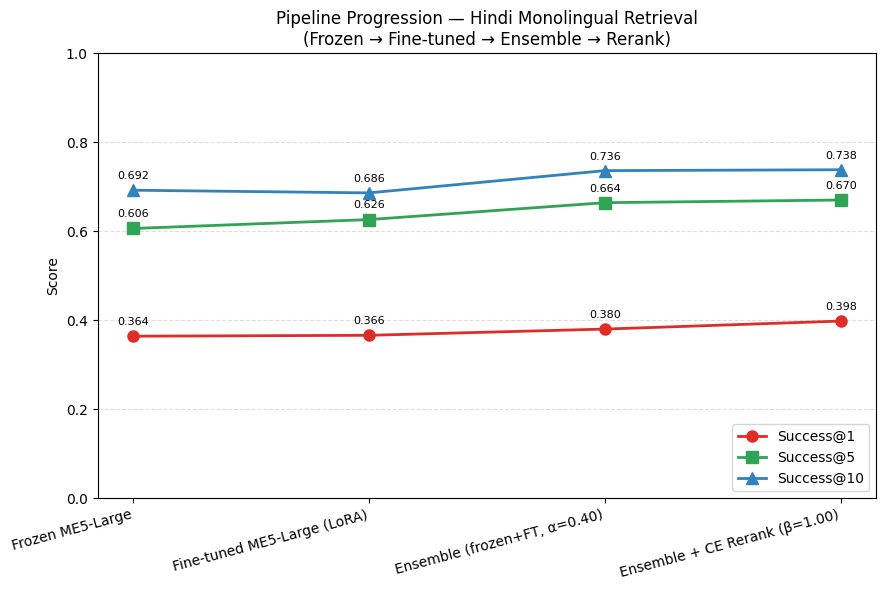

Saved chart to: /content/drive/MyDrive/semeval_hin_mono4sep_results/final_results_hin/pipeline_progression_hin.png


In [4]:
# ============================================================
# FINAL CELL C: PIPELINE PROGRESSION CHART — line plot per metric
# ============================================================
markers = ['o', 's', '^']
line_colors = ['#DE2D26', '#31A354', '#3182BD']

fig, ax = plt.subplots(figsize=(9, 6))
for metric, marker, c in zip(metrics, markers, line_colors):
    vals = final_table[metric].values
    ax.plot(stages, vals, marker=marker, color=c, linewidth=2, markersize=8,
             label=metric.replace('success', 'Success'))
    for xi, yi in zip(stages, vals):
        ax.annotate(f'{yi:.3f}', (xi, yi), textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=8)

ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('Pipeline Progression — Hindi Monolingual Retrieval\n(Frozen → Fine-tuned → Ensemble → Rerank)', fontsize=12)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
progression_chart_path = os.path.join(final_out_dir, 'pipeline_progression_hin.png')
plt.savefig(progression_chart_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved chart to: {progression_chart_path}')

In [5]:
# ============================================================
# FINAL CELL D: SAVE RAW RESULTS DICT AS JSON
# (backup — lets you regenerate the CSV/MD/charts later without
#  re-running any model or re-deriving these numbers by hand)
# ============================================================
import json

raw_results_hin = {
    'language': 'hin',
    'track': 'monolingual',
    'test_set_size': 500,
    'dev_set_size': 478,
    'hyperparameters': {
        'ensemble_alpha': hin_best_alpha,
        'rerank_beta': FINAL_BETA_HIN,
    },
    'results': {
        'frozen':            hin_results_frozen,
        'finetuned_lora':    hin_results_finetuned,
        'ensemble':          hin_results_ensemble,
        'ensemble_ce_rerank': hin_results_reranked_ft,
    },
}

json_path = os.path.join(final_out_dir, 'raw_results_hin.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(raw_results_hin, f, indent=2, ensure_ascii=False)

print(f'💾 Saved raw results backup to: {json_path}')
print(json.dumps(raw_results_hin, indent=2))

💾 Saved raw results backup to: /content/drive/MyDrive/semeval_hin_mono4sep_results/final_results_hin/raw_results_hin.json
{
  "language": "hin",
  "track": "monolingual",
  "test_set_size": 500,
  "dev_set_size": 478,
  "hyperparameters": {
    "ensemble_alpha": 0.4,
    "rerank_beta": 1.0
  },
  "results": {
    "frozen": {
      "success@1": 0.364,
      "success@5": 0.606,
      "success@10": 0.692
    },
    "finetuned_lora": {
      "success@1": 0.366,
      "success@5": 0.626,
      "success@10": 0.686
    },
    "ensemble": {
      "success@1": 0.38,
      "success@5": 0.664,
      "success@10": 0.736
    },
    "ensemble_ce_rerank": {
      "success@1": 0.398,
      "success@5": 0.67,
      "success@10": 0.738
    }
  }
}


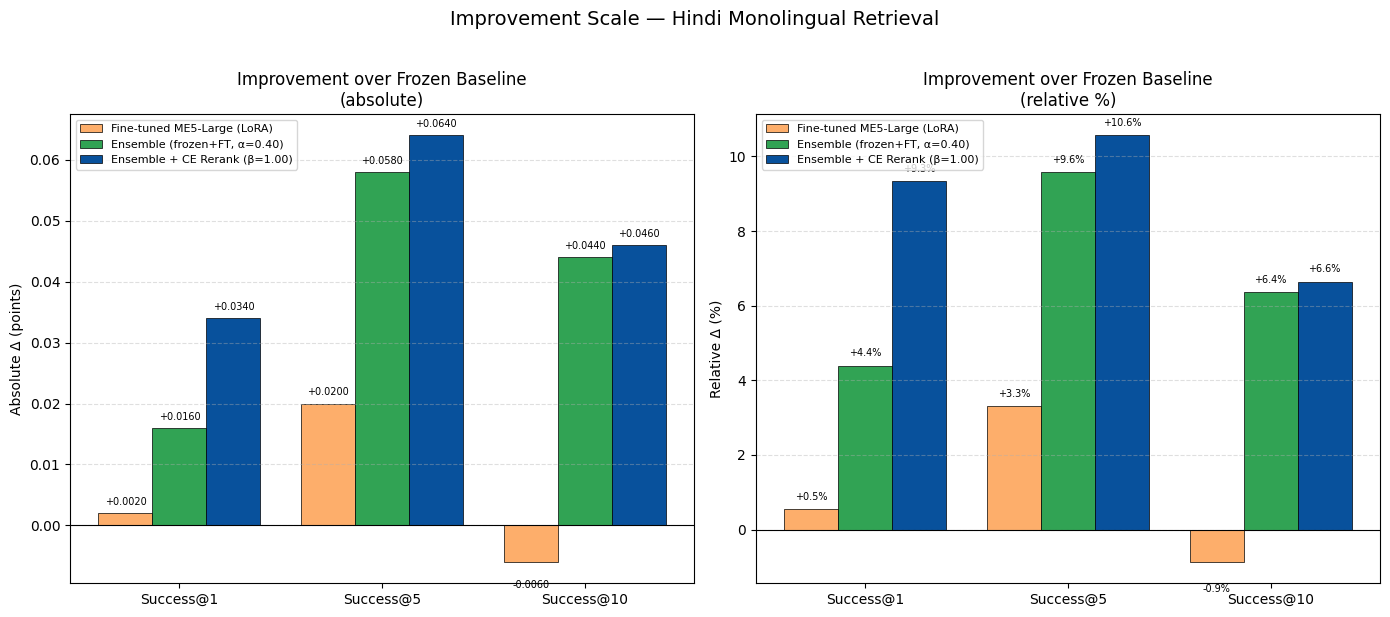

Saved chart to: /content/drive/MyDrive/semeval_hin_mono4sep_results/final_results_hin/improvement_scale_hin.png


In [6]:
# ============================================================
# FINAL CELL E: IMPROVEMENT SCALE CHART — Δ vs Frozen baseline
# (visualizes how much each stage adds, in absolute points and %)
# ============================================================
stages_no_baseline = [s for s in stages if s != 'Frozen ME5-Large']
bar_colors = ['#FDAE6B', '#31A354', '#08519C']  # fine-tuned, ensemble, ensemble+rerank

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: absolute point improvement ---
ax = axes[0]
x = np.arange(len(metrics))
width = 0.8 / len(stages_no_baseline)

for i, stage in enumerate(stages_no_baseline):
    vals = deltas.loc[stage, metrics].values
    offset = (i - (len(stages_no_baseline) - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=stage, color=bar_colors[i % len(bar_colors)],
                  edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, vals):
        y_pos = v + 0.001 if v >= 0 else v - 0.003
        ax.text(bar.get_x() + bar.get_width() / 2, y_pos, f'{v:+.4f}',
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=7)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['Success@1', 'Success@5', 'Success@10'])
ax.set_ylabel('Absolute Δ (points)')
ax.set_title('Improvement over Frozen Baseline\n(absolute)', fontsize=12)
ax.legend(fontsize=8, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# --- Right: percentage improvement ---
ax = axes[1]
for i, stage in enumerate(stages_no_baseline):
    vals = pct_deltas.loc[stage, metrics].values
    offset = (i - (len(stages_no_baseline) - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=stage, color=bar_colors[i % len(bar_colors)],
                  edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, vals):
        y_pos = v + 0.2 if v >= 0 else v - 0.6
        ax.text(bar.get_x() + bar.get_width() / 2, y_pos, f'{v:+.1f}%',
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=7)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['Success@1', 'Success@5', 'Success@10'])
ax.set_ylabel('Relative Δ (%)')
ax.set_title('Improvement over Frozen Baseline\n(relative %)', fontsize=12)
ax.legend(fontsize=8, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Improvement Scale — Hindi Monolingual Retrieval', fontsize=14, y=1.02)
plt.tight_layout()
improvement_scale_path = os.path.join(final_out_dir, 'improvement_scale_hin.png')
plt.savefig(improvement_scale_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved chart to: {improvement_scale_path}')